In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import keras
import sys

sys.path.append("..")

In [2]:
DATA_DIR = "../mu3e_trigger_data"
SIGNAL_PIXEL_FILE = f"{DATA_DIR}/run42_sig_pixel_128.npy"
BACKGROUND_PIXEL_FILE = f"{DATA_DIR}/run42_bg_pixel_128.npy"
SIGNAL_DATA_FILE = f"{DATA_DIR}/run42_sig_mppc_128.npy"
BACKGROUND_DATA_FILE = f"{DATA_DIR}/run42_bg_mppc_128.npy"

bg_pixel_spacetime = np.load(BACKGROUND_PIXEL_FILE)
sig_pixel_spacetime = np.load(SIGNAL_PIXEL_FILE)
bg_pixel_seqlen = (bg_pixel_spacetime != -1).all(axis=-1).sum(axis=-1)
sig_pixel_seqlen = (sig_pixel_spacetime != -1).all(axis=-1).sum(axis=-1)

input_seq_len = bg_pixel_spacetime.shape[1]
input_dim = bg_pixel_spacetime.shape[2]  # Exclude timestamp

from src.utils import cartesian_to_cylindrical

bg_pixel_cylindrical = np.concatenate(
    [
        cartesian_to_cylindrical(bg_pixel_spacetime[:, :, :2]),
        bg_pixel_spacetime[:, :, 2:],
    ],
    axis=-1,
)
sig_pixel_cylindrical = np.concatenate(
    [
        cartesian_to_cylindrical(sig_pixel_spacetime[:, :, :2]),
        sig_pixel_spacetime[:, :, 2:],
    ],
    axis=-1,
)

bg_seq_length = (bg_pixel_spacetime != -1).all(axis=-1).sum(axis=-1)
sig_seq_length = (sig_pixel_spacetime != -1).all(axis=-1).sum(axis=-1)

bg_pixel_spacetime = bg_pixel_spacetime[bg_pixel_seqlen > 0]
sig_pixel_spacetime = sig_pixel_spacetime[sig_pixel_seqlen > 0]
bg_pixel_cylindrical = bg_pixel_cylindrical[bg_pixel_seqlen > 0]
sig_pixel_cylindrical = sig_pixel_cylindrical[sig_pixel_seqlen > 0]
bg_seq_length = bg_seq_length[bg_pixel_seqlen > 0]
sig_seq_length = sig_seq_length[sig_pixel_seqlen > 0]

In [ ]:
from src.model.components import (
    MultiHeadAttentionBlock,
    MultiHeadAttentionStack,
    SelfAttentionBlock,
    SelfAttentionStack,
    PoolingAttentionBlock,
    GenerateMask,
    GetSequenceLength,
    DecoderQueries,
    GenerateDecoderMask,
    MLP,
    MaskOutput,
)

feature_dim = 8
latent_dim = 32
num_seeds = latent_dim // feature_dim
dropout_rate = 0.0

pixel_input = keras.layers.Input(shape=(input_seq_len, input_dim), name="pixel_input")
pixel_mask = GenerateMask(name="pixel_mask")(pixel_input)
pixel_seqlen = GetSequenceLength(name="pixel_seqlen")(pixel_mask)

pixel_embedding = MLP(
    num_layers=4,
    output_dim=feature_dim,
    name="pixel_embedding",
)(pixel_input)

pixel_self_attention = SelfAttentionStack(
    num_heads=4,
    key_dim=feature_dim,
    stack_size=3,
    name="pixel_self_attention",
)(pixel_embedding, pixel_mask)

pixel_pooling = PoolingAttentionBlock(
    key_dim=feature_dim,
    num_seeds=num_seeds,
    num_heads=4,
    name="pixel_pooling",
)(pixel_self_attention, pixel_mask)

pixel_latent_space = MLP(
    num_layers=4,
    output_dim=feature_dim,
    name="pixel_latent_space",
)(pixel_pooling)


pixel_latent_output = keras.layers.Flatten(name="pixel_latent_output")(
    pixel_latent_space
)


decoder_queries = DecoderQueries(
    num_queries=input_seq_len,
    feature_dim=feature_dim,
    name="decoder_queries",
)(pixel_seqlen)

decoded_embedded_queries = MLP(
    num_layers=4,
    output_dim=feature_dim,
    name="decoded_embedded_queries",
)(decoder_queries)


decoder_mask = GenerateDecoderMask(name="decoder_mask", max_length=128)(pixel_seqlen)

decoded_latent_set = MLP(
    num_layers=4,
    output_dim=feature_dim,
    name="decoded_latent_set",
)(pixel_latent_space)


decoded_pixel_space = MultiHeadAttentionBlock(
    num_heads=4,
    key_dim=feature_dim,
    name="decoded_pixel_space",
)(decoder_queries, decoded_latent_set, query_mask=decoder_mask)


decoded_point_set_self_attention = SelfAttentionStack(
    num_heads=4,
    key_dim=feature_dim,
    stack_size=3,
    name="decoded_point_set_self_attention",
)(decoded_pixel_space, decoder_mask)

decoded_point_set = MLP(
    num_layers=4,
    output_dim=input_dim,
    name="decoded_point_set_mlp",
    activation="linear",
)(decoded_point_set_self_attention)

decoded_output = MaskOutput(name="decoded_output", padding_value=-1)(
    decoded_point_set, decoder_mask
)

"""
seqlen_output = keras.layers.Concatenate(name="seqlen_output")(
    [
        keras.layers.Flatten(name="seqlen_flatten")(pixel_seqlen),
        keras.layers.Flatten(name="decoder_seqlen_flatten")(decoder_seqlen),
    ]
)"""

model = keras.Model(
    inputs=pixel_input,
    outputs=[decoded_output, pixel_latent_output],
    name="SetAutoEncoder",
)

from src.training import SplitMSE, ChamferDistanceMasked, EmbeddingSpaceSpreading

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss={
        "decoded_output": ChamferDistanceMasked(padding_value=-1, mode="cylindrical"),
        "pixel_latent_output": EmbeddingSpaceSpreading(),
    },
)

model.summary()

Model: "SetAutoEncoder"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ pixel_input         │ (None, 128, 4)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pixel_mask          │ (None, 128, 1)    │          0 │ pixel_input[0][0] │
│ (GenerateMask)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pixel_embedding     │ (None, 128, 8)    │        274 │ pixel_input[0][0] │
│ (MLP)               │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pixel_self_attenti… │ (None, 128, 8)    │      4,320 │ pixel_embedding[… │
│ (SelfAttentionStac… │                   │            │ pixel_mask[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pixel_pooling       │ (None, 4, 8)      │      1,472 │ pixel_self_atten… │
│ (PoolingAttentionB… │                   │            │ pixel_mask[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pixel_seqlen        │ (None, 1)         │          0 │ pixel_mask[0][0]  │
│ (GetSequenceLength) │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pixel_latent_space  │ (None, 4, 8)      │        576 │ pixel_pooling[0]… │
│ (MLP)               │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_queries     │ (None, 128, 8)    │      1,024 │ pixel_seqlen[0][… │
│ (DecoderQueries)    │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoded_latent_set  │ (None, 4, 8)      │        576 │ pixel_latent_spa… │
│ (MLP)               │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_mask        │ (None, 128, 1)    │          0 │ pixel_seqlen[0][… │
│ (GenerateDecoderMa… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoded_pixel_space │ (None, 128, 8)    │      1,440 │ decoder_queries[… │
│ (MultiHeadAttentio… │                   │            │ decoded_latent_s… │
│                     │                   │            │ decoder_mask[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoded_point_set_… │ (None, 128, 8)    │      4,320 │ decoded_pixel_sp… │
│ (SelfAttentionStac… │                   │            │ decoder_mask[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoded_point_set_… │ (None, 128, 4)    │        266 │ decoded_point_se… │
│ (MLP)               │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoded_output      │ (None, 128, 4)    │          0 │ decoded_point_se… │
│ (MaskOutput)        │                   │            │ decoder_mask[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pixel_latent_output │ (None, 32)        │          0 │ pixel_latent_spa… │
│ (Flatten)           │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 13,702 (53.52 KB)

 Trainable params: 13,702 (53.52 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
data = bg_pixel_cylindrical[:10000]
model.fit(
    x=data,
    y={
        "decoded_output": data,
        "pixel_latent_output": np.zeros((data.shape[0], latent_dim)),
    },
    batch_size=512,
    epochs=100,
    validation_split=0.1,
    shuffle=True,
    callbacks=[
        keras.callbacks.EarlyStopping(
            monitor="val_loss",
            patience=3,
            restore_best_weights=True,
        )
    ],
)

Epoch 1/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 19s 1s/step - decoded_output_loss: 419.5097 - loss: 437.1690 - pixel_latent_output_loss: 17.8047 - val_decoded_output_loss: 427.1294 - val_loss: 446.2715 - val_pixel_latent_output_loss: 19.4691
Epoch 2/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 19s 1s/step - decoded_output_loss: 392.9079 - loss: 411.2188 - pixel_latent_output_loss: 18.4666 - val_decoded_output_loss: 389.0568 - val_loss: 405.7284 - val_pixel_latent_output_loss: 17.2110
Epoch 3/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 20s 1s/step - decoded_output_loss: 371.7519 - loss: 389.2824 - pixel_latent_output_loss: 17.6887 - val_decoded_output_loss: 427.6348 - val_loss: 451.0162 - val_pixel_latent_output_loss: 23.8454
Epoch 4/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 20s 1s/step - decoded_output_loss: 386.9827 - loss: 410.9723 - pixel_latent_output_loss: 24.2126 - val_decoded_output_loss: 399.2601 - val_loss: 423.3240 - val_pixel_latent_output_loss: 24.4710
Epoch 5/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 23s 1s/step - decoded_output_

In [9]:
pred = model.predict(x=sig_pixel_cylindrical[:1], batch_size=10)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step


In [10]:
sig_pixel_cylindrical[:1]

array([[[ 2.32694273e+01,  2.69479457e-01, -4.53100000e+01,
          0.00000000e+00],
        [ 8.50881270e+01,  2.76647090e+00, -9.87100000e+01,
          0.00000000e+00],
        [ 7.20261274e+01,  6.60093691e-01, -5.25400000e+01,
          0.00000000e+00],
        [ 7.24421479e+01,  2.85626111e+00, -1.00420000e+02,
          0.00000000e+00],
        [ 2.95972237e+01,  3.31053545e-01, -4.62700000e+01,
          0.00000000e+00],
        [ 8.50634403e+01,  7.55333717e-01, -5.43500000e+01,
          0.00000000e+00],
        [ 3.00852464e+01,  1.33015494e-01, -2.22900000e+01,
          1.00000000e+00],
        [ 8.51986596e+01,  2.72740261e-01,  3.27000000e+00,
          1.00000000e+00],
        [ 2.37765062e+01,  1.52341326e-01, -2.50100000e+01,
          1.00000000e+00],
        [ 7.23020121e+01,  2.18464166e-01, -2.92000000e+00,
          1.00000000e+00],
        [ 2.96464846e+01, -1.51071935e+00, -4.74700000e+01,
          2.00000000e+00],
        [ 8.50881270e+01,  1.42007405e+00, 

In [11]:
encoder = keras.Model(
    inputs=model.inputs,
    outputs=pixel_latent_output,
    name="SetAutoEncoderEncoder",
)

encoder.predict(x=sig_pixel_cylindrical[:1], batch_size=10)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 172ms/step


array([[0.        , 0.12360161, 0.        , 0.        , 0.47749558,
        1.8694935 , 2.222597  , 1.1446776 , 0.        , 0.05259749,
        0.        , 0.        , 0.39848328, 1.6981544 , 1.9553182 ,
        0.99096894, 0.        , 0.0722854 , 0.        , 0.        ,
        0.4251293 , 1.7694758 , 2.0597548 , 1.0453129 , 0.        ,
        0.13963622, 0.        , 0.        , 0.49047288, 1.8950927 ,
        2.2580457 , 1.1677803 ]], dtype=float32)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step


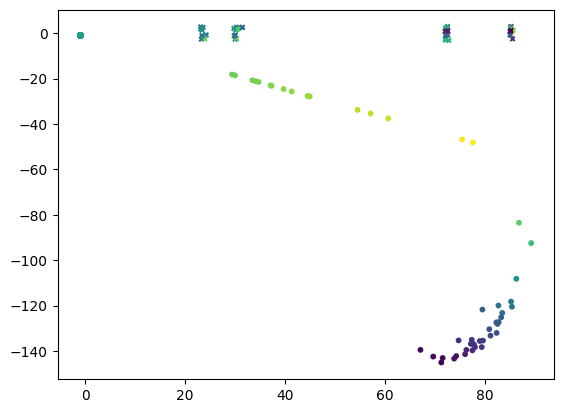

In [18]:
event = sig_pixel_cylindrical[1:2]
pred = model.predict(x=event, batch_size=10)
plt.scatter(
    pred[0][0, :, 0],
    pred[0][0, :, 1],
    c=pred[0][0, :, 2],
    s=10,
    marker="o",
)
plt.scatter(
    event[0, :, 0],
    event[0, :, 1],
    c=event[0, :, 2],
    s=10,
    marker="x",
)